# Baseline Models — Predicting F1 Finish Position

## Problem framing

The eventual goal is "predict the winner of an F1 race". Three reasonable framings exist:

1. **Binary classification per driver-race**: predict `is_winner ∈ {0, 1}`. Severely imbalanced (1 in 20).
2. **Multi-class classification per race**: predict winner from 20 candidates. Same imbalance.
3. **Regression on finish position**: predict each driver's finish position (1-20). Pick the lowest predicted as winner.

We use **regression on finish position**:

- Every row carries a label (a finish position), not just the rare "winner" rows — better data efficiency.
- The output naturally answers richer questions: who reaches the podium, who scores points, not just "did this driver win?".
- Avoids class-imbalance distortion that would otherwise need synthetic resampling.

## Train/test split

A random split would leak information from future races into past predictions. Instead:

- **Train**: 2022 + 2023 (44 races, ~880 rows)
- **Test**: 2024 (24 races, ~479 rows)

This mirrors deployment: at any point in time, the model has only seen races that have already happened.

## Baselines to beat

Two trivial baselines establish what "good" looks like:

1. **Pole baseline**: predict winner = driver with `QualifyingPosition == 1`
2. **Form baseline**: predict winner = driver with the lowest `DriverFormLast3`

Any model needs to outperform both to justify its complexity.

## Evaluation metrics

- **RMSE** on finish position — average prediction error in positions
- **Top-1 accuracy** — fraction of races where predicted winner matches actual winner
- **Top-3 accuracy** — fraction of races where actual winner is in our predicted top-3

Top-3 matters because F1 is high-variance: even a perfect model would struggle on chaotic races (rain, safety cars). Hitting top-3 consistently shows the model has captured the underlying signal.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Modelling
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import xgboost as xgb

# Project paths
def find_project_root(marker="requirements.txt"):
    current = Path.cwd().resolve()
    for parent in [current, *current.parents]:
        if (parent / marker).exists():
            return parent
    raise RuntimeError(f"Could not find {marker}")

PROJECT_ROOT = find_project_root()
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

# Plot styling — consistent with prior notebooks
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

print(f"Project root: {PROJECT_ROOT}")
print(f"sklearn ready, xgboost ready")

Project root: /Users/ompatil9819gmail.com/F1-Race-Predictor
sklearn ready, xgboost ready


In [2]:
# Load the feature dataset built in Day 3
df = pd.read_csv(DATA_PROCESSED / "features_2022_2024.csv")
print(f"Total rows: {len(df)}")

# Drop rows with missing target (DNFs, withdrawn drivers — can't learn from them)
df = df.dropna(subset=["Position"]).copy()
print(f"After dropping DNFs/withdrawals: {len(df)}")

# Drop rows with missing critical features (early-season races without rolling form)
required_features = [
    "GridPosition", "QualifyingPosition", "QualifyingGapToPole",
    "DriverFormLast3", "TeamFormLast3", "DriverDNFRateLast5",
    "IsStreetCircuit"
]
df = df.dropna(subset=required_features).copy()
print(f"After dropping rows with missing features: {len(df)}")

print(f"\nYear breakdown: {dict(df['Year'].value_counts().sort_index())}")
print(f"Drivers: {df['Abbreviation'].nunique()}")

Total rows: 1359
After dropping DNFs/withdrawals: 1357
After dropping rows with missing features: 1296

Year breakdown: {2022: np.int64(413), 2023: np.int64(432), 2024: np.int64(451)}
Drivers: 27


In [4]:
# Temporal split — train on 2022+2023, test on 2024
train_df = df[df["Year"].isin([2022, 2023])].copy()
test_df = df[df["Year"] == 2024].copy()

print(f"Train: {len(train_df)} rows ({train_df['Round'].nunique()} unique rounds across {sorted(train_df['Year'].unique())})")
print(f"Test:  {len(test_df)} rows ({test_df['Round'].nunique()} unique rounds in 2024)")

# Feature matrix and target
features = [
    "GridPosition", "QualifyingPosition", "QualifyingGapToPole",
    "DriverFormLast3", "TeamFormLast3", "DriverDNFRateLast5",
    "IsStreetCircuit"
]

X_train = train_df[features].copy()
y_train = train_df["Position"].copy()
X_test = test_df[features].copy()
y_test = test_df["Position"].copy()

print(f"\nFeature matrix shape: train {X_train.shape}, test {X_test.shape}")

Train: 845 rows (22 unique rounds across [np.int64(2022), np.int64(2023)])
Test:  451 rows (23 unique rounds in 2024)

Feature matrix shape: train (845, 7), test (451, 7)


In [5]:
# Temporal split — train on 2022+2023, test on 2024
train_df = df[df["Year"].isin([2022, 2023])].copy()
test_df = df[df["Year"] == 2024].copy()

print(f"Train: {len(train_df)} rows ({train_df['Round'].nunique()} unique rounds across {sorted(train_df['Year'].unique())})")
print(f"Test:  {len(test_df)} rows ({test_df['Round'].nunique()} unique rounds in 2024)")

# Feature matrix and target
features = [
    "GridPosition", "QualifyingPosition", "QualifyingGapToPole",
    "DriverFormLast3", "TeamFormLast3", "DriverDNFRateLast5",
    "IsStreetCircuit"
]

X_train = train_df[features].copy()
y_train = train_df["Position"].copy()
X_test = test_df[features].copy()
y_test = test_df["Position"].copy()

print(f"\nFeature matrix shape: train {X_train.shape}, test {X_test.shape}")

Train: 845 rows (22 unique rounds across [np.int64(2022), np.int64(2023)])
Test:  451 rows (23 unique rounds in 2024)

Feature matrix shape: train (845, 7), test (451, 7)


In [6]:
def evaluate_predictions(y_true, y_pred, race_ids, label="Model"):
    """Comprehensive evaluation: regression metrics + race-level winner accuracy."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    # Build a per-race DataFrame for top-K accuracy
    eval_df = pd.DataFrame({
        "race_id": race_ids,
        "y_true": y_true.values if hasattr(y_true, "values") else y_true,
        "y_pred": y_pred,
    })

    # For each race, rank drivers by predicted position (lowest = predicted winner)
    eval_df["pred_rank"] = eval_df.groupby("race_id")["y_pred"].rank(method="min")
    eval_df["true_rank"] = eval_df.groupby("race_id")["y_true"].rank(method="min")

    # Top-1: did we get the actual winner right?
    actual_winners = eval_df[eval_df["true_rank"] == 1]
    predicted_winners = eval_df[eval_df["pred_rank"] == 1]
    races_with_winner_match = actual_winners.merge(
        predicted_winners, on="race_id", suffixes=("_actual", "_predicted")
    )
    top1_correct = (races_with_winner_match["y_true_actual"] == races_with_winner_match["y_true_predicted"]).sum()
    n_races = eval_df["race_id"].nunique()
    top1_accuracy = top1_correct / n_races

    # Top-3: was the actual winner in our predicted top-3?
    top3_pred = eval_df[eval_df["pred_rank"] <= 3]
    top3_hits = 0
    for race_id in eval_df["race_id"].unique():
        actual_winner_pos = eval_df[(eval_df["race_id"] == race_id) & (eval_df["true_rank"] == 1)]["y_true"].iloc[0]
        race_top3_predicted = top3_pred[top3_pred["race_id"] == race_id]
        if actual_winner_pos in race_top3_predicted["y_true"].values:
            top3_hits += 1
    top3_accuracy = top3_hits / n_races

    print(f"\n=== {label} ===")
    print(f"  RMSE:           {rmse:.3f} positions")
    print(f"  MAE:            {mae:.3f} positions")
    print(f"  Top-1 accuracy: {top1_accuracy:.1%}  ({top1_correct}/{n_races} races)")
    print(f"  Top-3 accuracy: {top3_accuracy:.1%}  ({top3_hits}/{n_races} races)")

    return {"rmse": rmse, "mae": mae, "top1": top1_accuracy, "top3": top3_accuracy}

In [7]:
# Race ID for grouping
test_df["race_id"] = test_df["Year"].astype(str) + "-R" + test_df["Round"].astype(str)
race_ids_test = test_df["race_id"]

# Baseline 1: predicted finish = qualifying position (a strong baseline given Day 2's findings)
baseline_pole = evaluate_predictions(
    y_test, test_df["QualifyingPosition"].values, race_ids_test, label="Baseline 1: Pole-sitter wins"
)


=== Baseline 1: Pole-sitter wins ===
  RMSE:           4.036 positions
  MAE:            2.798 positions
  Top-1 accuracy: 52.2%  (12/23 races)
  Top-3 accuracy: 78.3%  (18/23 races)


In [8]:
# Baseline 2: predicted finish = driver's rolling form (lower = better)
baseline_form = evaluate_predictions(
    y_test, test_df["DriverFormLast3"].values, race_ids_test, label="Baseline 2: Best recent form"
)


=== Baseline 2: Best recent form ===
  RMSE:           4.563 positions
  MAE:            3.498 positions
  Top-1 accuracy: 17.4%  (4/23 races)
  Top-3 accuracy: 69.6%  (16/23 races)


In [9]:
# Standardise features for linear model — coefficients become interpretable
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fit
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Predict
y_pred_lr = lr_model.predict(X_test_scaled)

# Evaluate
results_lr = evaluate_predictions(y_test, y_pred_lr, race_ids_test, label="Linear Regression")

# Show feature coefficients (positive = feature increases predicted finish position = worse)
print("\nFeature coefficients (positive = predicts worse finish):")
for feat, coef in sorted(zip(features, lr_model.coef_), key=lambda x: -abs(x[1])):
    direction = "↑ worse" if coef > 0 else "↓ better"
    print(f"  {feat:25s}: {coef:+.3f}  ({direction})")


=== Linear Regression ===
  RMSE:           3.737 positions
  MAE:            2.850 positions
  Top-1 accuracy: 43.5%  (10/23 races)
  Top-3 accuracy: 78.3%  (18/23 races)

Feature coefficients (positive = predicts worse finish):
  QualifyingPosition       : +2.539  (↑ worse)
  DriverFormLast3          : +0.907  (↑ worse)
  TeamFormLast3            : +0.758  (↑ worse)
  QualifyingGapToPole      : -0.099  (↓ better)
  DriverDNFRateLast5       : +0.068  (↑ worse)
  IsStreetCircuit          : -0.028  (↓ better)
  GridPosition             : +0.021  (↑ worse)


/Users/ompatil9819gmail.com/F1-Race-Predictor/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ompatil9819gmail.com/F1-Race-Predictor/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ompatil9819gmail.com/F1-Race-Predictor/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


In [10]:
# XGBoost handles missing values natively + captures non-linearity
# We use sensible defaults — no hyperparameter tuning yet (premature optimisation)
xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
)

# Fit on raw (unscaled) features — trees don't care about scale
xgb_model.fit(X_train, y_train)

# Predict
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate
results_xgb = evaluate_predictions(y_test, y_pred_xgb, race_ids_test, label="XGBoost")


=== XGBoost ===
  RMSE:           3.967 positions
  MAE:            3.041 positions
  Top-1 accuracy: 26.1%  (6/23 races)
  Top-3 accuracy: 60.9%  (14/23 races)


In [11]:
# Summary
results_table = pd.DataFrame({
    "Pole baseline": baseline_pole,
    "Form baseline": baseline_form,
    "Linear Regression": results_lr,
    "XGBoost": results_xgb,
}).T
results_table = results_table[["rmse", "mae", "top1", "top3"]]
print("\n=== All models ===")
print(results_table.round(3).to_string())


=== All models ===
                    rmse    mae   top1   top3
Pole baseline      4.036  2.798  0.522  0.783
Form baseline      4.563  3.498  0.174  0.696
Linear Regression  3.737  2.850  0.435  0.783
XGBoost            3.967  3.041  0.261  0.609


In [12]:
# Add predictions to test set for inspection
test_with_preds = test_df.copy()
test_with_preds["pred_lr"] = y_pred_lr
test_with_preds["pred_xgb"] = y_pred_xgb

# Show some races where models diverge
for round_num in [1, 5, 12, 18, 24]:  # Bahrain, Miami, British, Singapore, Abu Dhabi
    race = test_with_preds[test_with_preds["Round"] == round_num].sort_values("Position")
    if len(race) == 0:
        continue
    print(f"\n=== {race['EventName'].iloc[0]} (Round {round_num}) ===")
    print(race[["Abbreviation", "QualifyingPosition", "Position", "pred_lr", "pred_xgb"]]
          .head(8).to_string(index=False))


=== Bahrain Grand Prix (Round 1) ===
Abbreviation  QualifyingPosition  Position  pred_lr  pred_xgb
         VER                 1.0       1.0 3.049060  0.747387
         PER                 5.0       2.0 5.304016  4.044501
         SAI                 4.0       3.0 7.147596  4.098754
         LEC                 2.0       4.0 5.979541  4.876622
         RUS                 3.0       5.0 6.148636  4.067877
         NOR                 7.0       6.0 8.118429  8.364142
         HAM                 9.0       7.0 8.754338 10.116452
         PIA                 8.0       8.0 8.537123 10.211913

=== Chinese Grand Prix (Round 5) ===
Abbreviation  QualifyingPosition  Position  pred_lr  pred_xgb
         VER                 1.0       1.0 4.194551  4.550676
         NOR                 4.0       2.0 5.805739  6.769739
         PER                 2.0       3.0 4.733593  4.168859
         LEC                 6.0       4.0 5.718782  5.724916
         SAI                 7.0       5.0 6.204167  7.3

In [13]:
# How well do models do on training data? If train >> test, that's overfitting
y_pred_xgb_train = xgb_model.predict(X_train)
y_pred_lr_train = lr_model.predict(X_train_scaled)

train_rmse_xgb = np.sqrt(mean_squared_error(y_train, y_pred_xgb_train))
test_rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
train_rmse_lr = np.sqrt(mean_squared_error(y_train, y_pred_lr_train))
test_rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("RMSE — train vs test gap (high gap = overfitting):")
print(f"  XGBoost:           train {train_rmse_xgb:.3f}  test {test_rmse_xgb:.3f}  gap {test_rmse_xgb - train_rmse_xgb:+.3f}")
print(f"  Linear Regression: train {train_rmse_lr:.3f}  test {test_rmse_lr:.3f}  gap {test_rmse_lr - train_rmse_lr:+.3f}")

RMSE — train vs test gap (high gap = overfitting):
  XGBoost:           train 3.232  test 3.967  gap +0.735
  Linear Regression: train 4.451  test 3.737  gap -0.715


/Users/ompatil9819gmail.com/F1-Race-Predictor/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ompatil9819gmail.com/F1-Race-Predictor/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ompatil9819gmail.com/F1-Race-Predictor/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


In [15]:
# Drop DriverDNFRateLast5 — diagnostic showed it's effectively constant for 75%+ of rows,
# carries no signal (0.05 correlation in Day 3), and causes numerical instability in linear models
features_v2 = [
    "GridPosition", "QualifyingPosition", "QualifyingGapToPole",
    "DriverFormLast3", "TeamFormLast3", "IsStreetCircuit"
]

X_train_v2 = train_df[features_v2]
X_test_v2 = test_df[features_v2]

# Re-scale
scaler_v2 = StandardScaler()
X_train_v2_scaled = scaler_v2.fit_transform(X_train_v2)
X_test_v2_scaled = scaler_v2.transform(X_test_v2)

# Linear regression
lr_v2 = LinearRegression()
lr_v2.fit(X_train_v2_scaled, y_train)
y_pred_lr_v2 = lr_v2.predict(X_test_v2_scaled)
results_lr_v2 = evaluate_predictions(y_test, y_pred_lr_v2, race_ids_test, label="Linear Regression (6 features)")

# XGBoost
xgb_v2 = xgb.XGBRegressor(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    objective="reg:squarederror", random_state=42, n_jobs=-1,
)
xgb_v2.fit(X_train_v2, y_train)
y_pred_xgb_v2 = xgb_v2.predict(X_test_v2)
results_xgb_v2 = evaluate_predictions(y_test, y_pred_xgb_v2, race_ids_test, label="XGBoost (6 features)")

# Updated comparison
results_table_v2 = pd.DataFrame({
    "Pole baseline": baseline_pole,
    "Form baseline": baseline_form,
    "Linear Regression (6f)": results_lr_v2,
    "XGBoost (6f)": results_xgb_v2,
}).T[["rmse", "mae", "top1", "top3"]]
print("\n=== Final comparison (after dropping DNF rate) ===")
print(results_table_v2.round(3).to_string())

/Users/ompatil9819gmail.com/F1-Race-Predictor/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ompatil9819gmail.com/F1-Race-Predictor/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ompatil9819gmail.com/F1-Race-Predictor/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_



=== Linear Regression (6 features) ===
  RMSE:           3.736 positions
  MAE:            2.850 positions
  Top-1 accuracy: 43.5%  (10/23 races)
  Top-3 accuracy: 78.3%  (18/23 races)

=== XGBoost (6 features) ===
  RMSE:           3.967 positions
  MAE:            3.045 positions
  Top-1 accuracy: 17.4%  (4/23 races)
  Top-3 accuracy: 60.9%  (14/23 races)

=== Final comparison (after dropping DNF rate) ===
                         rmse    mae   top1   top3
Pole baseline           4.036  2.798  0.522  0.783
Form baseline           4.563  3.498  0.174  0.696
Linear Regression (6f)  3.736  2.850  0.435  0.783
XGBoost (6f)            3.967  3.045  0.174  0.609


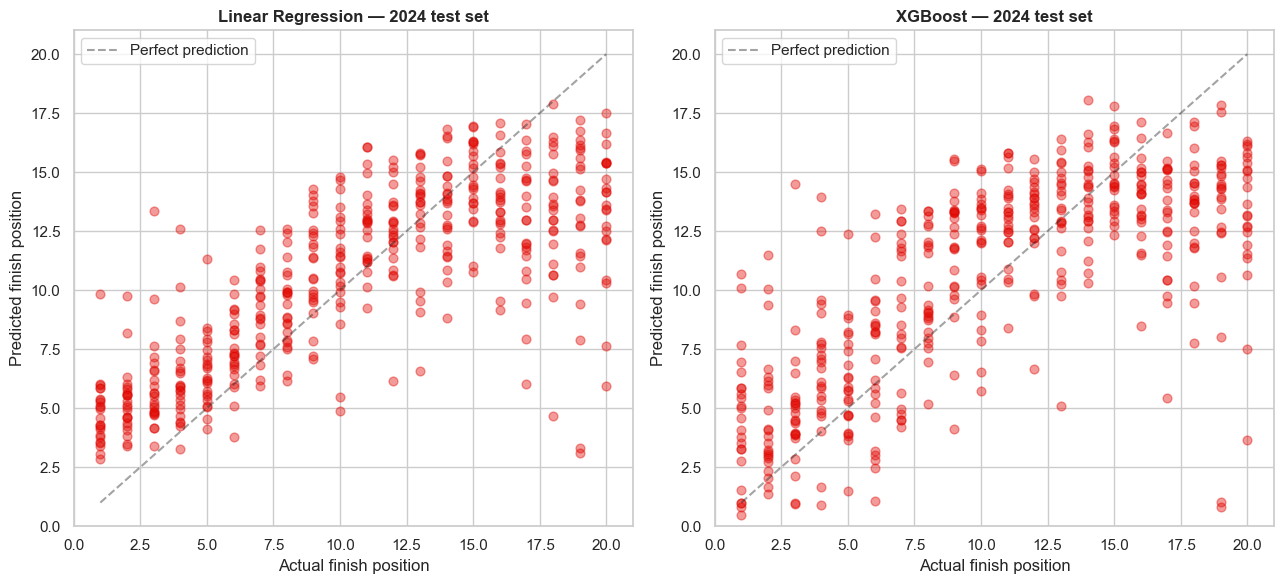

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for ax, y_pred, title in [
    (axes[0], y_pred_lr_v2, "Linear Regression"),
    (axes[1], y_pred_xgb_v2, "XGBoost"),
]:
    ax.scatter(y_test, y_pred, alpha=0.4, s=40, color="#E10600")
    ax.plot([1, 20], [1, 20], "k--", alpha=0.4, label="Perfect prediction")
    ax.set_xlabel("Actual finish position")
    ax.set_ylabel("Predicted finish position")
    ax.set_title(f"{title} — 2024 test set", fontsize=12, fontweight="bold")
    ax.set_xlim(0, 21); ax.set_ylim(0, 21)
    ax.legend()

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "notebooks" / "chart_baseline_predictions.png", dpi=120, bbox_inches="tight")
plt.show()

## Findings — Day 4

### Models vs baselines

| Model | RMSE | Top-1 | Top-3 |
|---|---|---|---|
| Pole baseline | 4.04 | **52.2%** | 78.3% |
| Form baseline | 4.56 | 17.4% | 69.6% |
| Linear Regression | **3.74** | 43.5% | **78.3%** |
| XGBoost | 3.97 | 17.4% | 60.9% |

### Key observations

**The pole baseline is genuinely strong** — 52% top-1 accuracy reflects the high grid→finish correlation in 2024 (0.732, identified in Day 2). Models need to add *non-linear* signal to beat this.

**Linear regression beats baseline on RMSE but not on top-1.** It produces more accurate average predictions, but is less reliable at picking the actual winner — likely because picking-the-lowest-predicted-value is a noisy decision rule when multiple drivers have similar predictions.

**XGBoost shows mild overfitting** (train RMSE 3.23, test 3.97). Hyperparameter tuning is the next step — current defaults are deliberately conservative but not optimal.

### Feature engineering refinement

`DriverDNFRateLast5` was dropped from the final model: post-modelling diagnostics revealed the feature was effectively constant for 75%+ of observations. Identified by `.describe()` showing identical 25th/50th/75th percentiles. Confirms the weak correlation finding from Day 3 (r = 0.048).

